# Multi-Domain CNN for Sub-Pixel Position Reconstruction in 3D Silicon Detectors

## Model Training & Evaluation Pipeline

**Task:** Reconstruct the $(x, y)$ laser impact position within a single pixel of a
3D columnar silicon detector using the Two-Photon Absorption Transient Current
Technique (TPA-TCT).

**Input:** Pre-processed features from the companion **NB_Feature_Engineering** notebook,
exported as `model_input.npz`. This file contains the complete 110-d MLP feature vector 
(already scaled), the 2-channel CNN waveform input, C₂v-folded targets, quadrant labels,
and a spatially stratified train/test split. No further feature engineering is needed here.

**Architecture:** A dual-branch neural network combining:
- **1D-CNN** processing 2-channel waveforms (raw signal + dV/dt derivative, 90 time bins)
- **MLP** processing 110 hand-crafted features (scalars, hierarchical PCA modes, C₂v IRREP features, radial distance)

The two branches are fused and feed three prediction heads:
1. **Regression head** → $(|u|, |v|)$ in the C₂v fundamental domain
2. **Quadrant classifier** → 4-class sector label for sign recovery
3. **U-sign auxiliary head** → binary classifier targeting the main confusion axis

**Training strategy:**
- **Phase 1:** CosineAnnealingWarmRestarts (800 epochs, 8 cycles) with snapshot ensemble
- **Phase 2:** ReduceLROnPlateau fine-tuning from the best Phase 1 snapshot

**Hyperparameters:** Optuna HPO v4, trial #1 (Soft=2.127 µm) — precision-focused, symmetry locked

**Post-processing:** Ensemble selection → Temperature optimisation → Confidence-gated soft-unfold → Test-Time Augmentation (TTA)

---
*Companion notebook: **NB_Feature_Engineering** (feature construction, analysis, and dataset export)*

In [1]:
# ============================================================
# §1  Imports and Data Loading
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, time, copy, random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix

plt.rcParams.update({'figure.figsize': (10, 7), 'font.size': 12, 'figure.dpi': 100})

# --- Reproducibility: fix ALL random seeds ---
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# For fully deterministic behaviour on CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# Force ALL PyTorch ops to use deterministic algorithms (matches Optuna setup)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
torch.use_deterministic_algorithms(True)

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device} | Seed: {SEED}')
print(f'  Deterministic algorithms: ON')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# --- Load pre-processed dataset from NB_Feature_Engineering ---
# The model_input.npz file contains all features (already scaled),
# targets, labels, split indices, and geometry parameters.
DATA_DIR = Path('.')  # or '/kaggle/working/' if running on Kaggle
if os.path.exists('/kaggle/input/notebooks/ibongarciagomez/nb01-physics-informed-feature-engineering'):
    DATA_DIR = Path('/kaggle/input/notebooks/ibongarciagomez/nb01-physics-informed-feature-engineering')
elif os.path.exists('model_input.npz'):
    DATA_DIR = Path('.')
else:
    raise FileNotFoundError(
        "model_input.npz not found. Run NB_Feature_Engineering first.")

data = np.load(DATA_DIR / 'model_input.npz')

# Model inputs (already scaled by NB_Feature_Engineering)
all_scalars         = data['mlp_input']              # (N, 110)
wf_2ch              = data['cnn_input']              # (N, 2, 90)

# Targets
targets_fund_scaled = data['targets_fund_scaled']    # (N, 2) scaled |u|, |v|
targets_xy          = data['targets_xy']             # (N, 2) raw x, y in µm
targets_fund        = data['targets_fund']           # (N, 2) |u|, |v| unscaled

# Labels
q_all               = data['quadrant']               # (N,)  int64
u_sign_all          = data['u_sign']                 # (N,)  float32
r_all               = data['radius']                 # (N,)

# Split indices
idx_train           = data['idx_train']
idx_test            = data['idx_test']

# Target scaler parameters (for inverse transform during evaluation)
target_mean         = data['target_mean']            # (2,)
target_scale        = data['target_scale']           # (2,)

# Geometry
geom                = data['geometry']               # [X_C, Y_C, PHI0]
X_C, Y_C, PHI0     = float(geom[0]), float(geom[1]), float(geom[2])

# Dimensions
dims                = data['dims']
# [n_scalars, n_wf_pca, n_dv_pca, n_fft_pca, n_irrep, n_mlp_in, n_bins, n_sectors]
N_SCALARS    = int(dims[0])
N_ASYM_WF    = int(dims[1])
N_ASYM_DERIV = int(dims[2])
N_ASYM_FFT   = int(dims[3])
N_IRREP      = int(dims[4])
N_MLP_IN     = int(dims[5])
N_BINS       = int(dims[6])
N_SECTORS    = int(dims[7])

# Convenience aliases
N             = len(q_all)
xf_all        = targets_fund[:, 0]
yf_all        = targets_fund[:, 1]

# Create a simple namespace to mimic sklearn target_scaler interface
class _TargetScaler:
    def __init__(self, mean, scale):
        self.mean_ = mean
        self.scale_ = scale
target_scaler = _TargetScaler(target_mean, target_scale)

# Summary
print(f'\nLoaded model_input.npz:')
print(f'  Events:    {N:,}')
print(f'  MLP input: {all_scalars.shape}  ({N_MLP_IN}-d)')
print(f'  CNN input: {wf_2ch.shape}  (2-ch × {N_BINS} bins)')
print(f'  Features:  {N_SCALARS} scalars + {N_ASYM_WF} wf-PCA + '
      f'{N_ASYM_DERIV} dV/dt-PCA + {N_ASYM_FFT} FFT-PCA + '
      f'{N_IRREP} IRREP + 1 radius = {N_MLP_IN}')
print(f'  Targets:   |u| ∈ [{xf_all.min():.2f}, {xf_all.max():.2f}]  '
      f'|v| ∈ [{yf_all.min():.2f}, {yf_all.max():.2f}] µm')
print(f'  Quadrants: {dict(zip(*np.unique(q_all, return_counts=True)))}')
print(f'  Geometry:  centre=({X_C:.2f}, {Y_C:.2f}) µm, φ₀={PHI0:.2f}°')
print(f'  Split:     Train {len(idx_train):,} / Test {len(idx_test):,} '
      f'({len(idx_test)/N:.1%} test)')

PyTorch 2.9.0+cu126 | Device: cuda | Seed: 2026
  Deterministic algorithms: ON
   GPU: Tesla P100-PCIE-16GB

Loaded model_input.npz:
  Events:    17,473
  MLP input: (17473, 110)  (110-d)
  CNN input: (17473, 2, 90)  (2-ch × 90 bins)
  Features:  11 scalars + 25 wf-PCA + 25 dV/dt-PCA + 15 FFT-PCA + 33 IRREP + 1 radius = 110
  Targets:   |u| ∈ [0.00, 41.61]  |v| ∈ [0.02, 37.52] µm
  Quadrants: {np.int64(0): np.int64(4466), np.int64(1): np.int64(4639), np.int64(2): np.int64(4295), np.int64(3): np.int64(4073)}
  Geometry:  centre=(-0.75, -1.46) µm, φ₀=89.27°
  Split:     Train 13,871 / Test 3,602 (20.6% test)


In [2]:
# ============================================================
# §2  Dataset and DataLoader
# ============================================================

class MultiDomainDataset(Dataset):
    """Dataset providing 2-channel CNN waveforms + scalar/PCA/IRREP MLP features."""

    def __init__(self, indices, wf_2ch, scalars_all, targets_uv,
                 targets_xy_orig, q, u_sign, augment=False):
        self.wf_2ch  = torch.tensor(wf_2ch[indices], dtype=torch.float32)
        self.scalars = torch.tensor(scalars_all[indices], dtype=torch.float32)
        self.uv      = torch.tensor(targets_uv[indices], dtype=torch.float32)
        self.xy      = torch.tensor(targets_xy_orig[indices], dtype=torch.float32)
        self.q       = torch.tensor(q[indices], dtype=torch.long)
        self.u_sign  = torch.tensor(u_sign[indices], dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.q)

    def __getitem__(self, i):
        wf = self.wf_2ch[i]
        if self.augment:
            wf = self._augment(wf)
        return wf, self.scalars[i], self.uv[i], self.xy[i], self.q[i], self.u_sign[i]

    @staticmethod
    def _augment(wf):
        """Conservative waveform augmentations (noise, shift, scale)."""
        # Optuna-optimised: trial #71 (Soft=2.131 µm)
        if torch.rand(1) < 0.5:
            wf = wf + torch.randn(1, wf.shape[1]) * 0.023
        if torch.rand(1) < 0.5:
            shift = torch.randint(-3, 4, (1,)).item()
            wf = torch.roll(wf, shift, dims=-1)
        if torch.rand(1) < 0.3:
            wf = wf * (0.948 + torch.rand(1).item() * 0.104)  # ±0.052
        return wf


ds_train = MultiDomainDataset(
    idx_train, wf_2ch, all_scalars,
    targets_fund_scaled, targets_xy, q_all, u_sign_all, augment=True)
ds_test = MultiDomainDataset(
    idx_test, wf_2ch, all_scalars,
    targets_fund_scaled, targets_xy, q_all, u_sign_all, augment=False)

BATCH = 384     # Optuna trial #71

g = torch.Generator()
g.manual_seed(SEED)

dl_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True,
                      generator=g)
dl_test  = DataLoader(ds_test, batch_size=BATCH, shuffle=False,
                      num_workers=2, pin_memory=True)

# Verify shapes
for wf_b, sc_b, uv_b, xy_b, q_b, us_b in dl_train:
    print(f'Batch shapes:')
    print(f'  CNN input:     {wf_b.shape}  (2 channels × {N_BINS} bins)')
    print(f'  MLP input:     {sc_b.shape}  ({N_MLP_IN} features)')
    print(f'  Target (|u|,|v|): {uv_b.shape}')
    print(f'  Quadrant:      {q_b.shape}')
    print(f'  U-sign:        {us_b.shape}')
    break

Batch shapes:
  CNN input:     torch.Size([384, 2, 90])  (2 channels × 90 bins)
  MLP input:     torch.Size([384, 110])  (110 features)
  Target (|u|,|v|): torch.Size([384, 2])
  Quadrant:      torch.Size([384])
  U-sign:        torch.Size([384])


## §3  Model Architecture

The **MultiDomainCNN** consists of:

| Component | Architecture | Output dim |
|-----------|-------------|-----------|
| **CNN branch** | Conv1d(2→32→64→128) + 3 ResBlocks + AdaptiveAvgPool | 128 |
| **MLP branch** | Linear(110→160→128→128) + BN + GELU + Dropout | 128 |
| **Fusion** | Linear(256→128→128) + BN + GELU | 128 |
| **head_xy** | Linear(128→96→48→2) | 2 (regression) |
| **head_sector** | Linear(128→96→48→4) | 4 (classification) |
| **head_usign** | Linear(128→48→1) | 1 (binary aux) |

The **u-sign auxiliary head** explicitly targets the dominant confusion axis
(Q0↔Q3, Q1↔Q2 swaps), providing a dedicated gradient signal for the
fusion layer to learn the up/down asymmetry encoded in the $B_2$ IRREP features.

In [3]:
# ============================================================
# §3a  Model Definition: MultiDomainCNN
# ============================================================

class ResBlock1D(nn.Module):
    """Pre-activation residual block for 1D convolutions."""
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class MultiDomainCNN(nn.Module):
    """
    Dual-branch CNN+MLP with three prediction heads.

    CNN: 2-channel waveform (raw + derivative) → 128-d embedding
    MLP: 110-d scalar/PCA/IRREP features → 128-d embedding
    Fusion: concatenation → 128-d → three heads

    Architecture tuned by Optuna trial #71 (Soft=2.131 µm).
    """
    def __init__(self, n_mlp_in=99, n_sectors=4):
        super().__init__()

        # === CNN branch: (batch, 2, 90) → (batch, 128) ===
        self.cnn_stem = nn.Sequential(
            nn.Conv1d(2, 32, 7, padding=3), nn.BatchNorm1d(32), nn.GELU(), nn.MaxPool1d(2))
        self.cnn_res1 = ResBlock1D(32)
        self.cnn_mid = nn.Sequential(
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.GELU(), nn.MaxPool1d(2))
        self.cnn_res2 = ResBlock1D(64)
        self.cnn_deep = nn.Sequential(
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2))
        self.cnn_res3 = ResBlock1D(128)
        self.cnn_head = nn.Sequential(
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(),
            nn.AdaptiveAvgPool1d(1))

        # === MLP branch: n_mlp_in → 128 ===
        # Optuna: mlp_hidden=128 (was 160), dropout_mlp=0.227 (was 0.1)
        self.mlp = nn.Sequential(
            nn.Linear(n_mlp_in, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.227),
            nn.Linear(128, 128),      nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.227),
            nn.Linear(128, 128),      nn.BatchNorm1d(128), nn.GELU())

        # === Fusion: 256 → 128 ===
        # Optuna: dropout_fusion=0.038 (was 0.1)
        self.fusion = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.038),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.GELU())

        # === Prediction heads ===
        self.head_xy = nn.Sequential(
            nn.Linear(128, 96), nn.GELU(), nn.Dropout(0.05),
            nn.Linear(96, 48),  nn.GELU(), nn.Linear(48, 2))
        self.head_sector = nn.Sequential(
            nn.Linear(128, 96), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(96, 48),  nn.GELU(), nn.Linear(48, n_sectors))
        self.head_usign = nn.Sequential(
            nn.Linear(128, 48), nn.GELU(), nn.Dropout(0.1), nn.Linear(48, 1))

    def forward(self, wf_2ch, scalars):
        # CNN
        x = self.cnn_stem(wf_2ch)
        x = self.cnn_res1(x)
        x = self.cnn_mid(x)
        x = self.cnn_res2(x)
        x = self.cnn_deep(x)
        x = self.cnn_res3(x)
        cnn_out = self.cnn_head(x).squeeze(-1)
        # MLP
        mlp_out = self.mlp(scalars)
        # Fusion + heads
        fused = self.fusion(torch.cat([cnn_out, mlp_out], dim=1))
        return self.head_xy(fused), self.head_sector(fused), self.head_usign(fused)


model = MultiDomainCNN(n_mlp_in=N_MLP_IN, n_sectors=N_SECTORS).to(device)
n_params = sum(p.numel() for p in model.parameters())

# Parameter breakdown
components = [('cnn_', 'CNN'), ('mlp', 'MLP'), ('fusion', 'Fusion'),
              ('head_xy', 'head_xy'), ('head_sector', 'head_sector'),
              ('head_usign', 'head_usign')]
print(f'MultiDomainCNN: {n_params:,} parameters')
for prefix, name in components:
    p = sum(p.numel() for n, p in model.named_parameters() if prefix in n)
    print(f'  {name:>15}: {p:,}')

MultiDomainCNN: 354,375 parameters
              CNN: 215,840
              MLP: 48,000
           Fusion: 49,920
          head_xy: 17,138
      head_sector: 17,236
       head_usign: 6,241


In [4]:
# ============================================================
# §4  Loss Function: LogCosh + Focal + Soft-Unfold + U-sign BCE
# ============================================================
#
# The composite loss has four terms:
#   L = λ_fund · LogCosh(|u|,|v|)     — smooth regression
#     + λ_focal · Focal(quadrant)      — weighted quadrant classification
#     + λ_soft  · LogCosh(soft-unfold) — differentiable full-space consistency
#     + λ_usign · BCE(u-sign)          — binary auxiliary for the main confusion axis
#
# Weights and focal config optimised by Optuna trial #71 (Soft=2.131 µm).

# C2v sign tables
U_SIGNS = torch.tensor([1.0,  1.0, -1.0, -1.0], device=device)
V_SIGNS = torch.tensor([1.0, -1.0, -1.0,  1.0], device=device)


def log_cosh_loss(pred, target):
    """LogCosh loss: smooth, robust, twice-differentiable alternative to L1."""
    diff = pred - target
    return torch.mean(torch.abs(diff) + F.softplus(-2.0 * torch.abs(diff)) - np.log(2))


class FocalLoss(nn.Module):
    """Focal Loss with per-class weighting: (1 - p_t)^γ · CE(p_t)."""
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce)
        loss = (1 - p_t) ** self.gamma * ce
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean() if self.reduction == 'mean' else loss


def soft_unfold_torch(u_abs, v_abs, logits, xc, yc, phi0_deg, temperature=0.1):
    """Differentiable soft-unfolding: (|u|, |v|, logits) → (x, y)."""
    probs = F.softmax(logits / temperature, dim=1)
    alpha_u = (probs * U_SIGNS).sum(dim=1)
    alpha_v = (probs * V_SIGNS).sum(dim=1)
    phi_r = torch.tensor(np.radians(phi0_deg), dtype=torch.float32, device=u_abs.device)
    u_s, v_s = u_abs * alpha_u, v_abs * alpha_v
    x = xc + torch.cos(phi_r) * u_s - torch.sin(phi_r) * v_s
    y = yc + torch.sin(phi_r) * u_s + torch.cos(phi_r) * v_s
    return x, y


# --- Optuna v4 trial #1 (Soft=2.127 µm) ---
# Focal loss: per-quadrant alpha weights + gamma (frozen from trial #71)
focal_loss = FocalLoss(gamma=1.873,
                       alpha=[0.894, 0.867, 1.345, 1.091]).to(device)

# Loss hyperparameters
T_SCALE = torch.tensor(target_scaler.scale_, dtype=torch.float32, device=device)
T_MEAN  = torch.tensor(target_scaler.mean_,  dtype=torch.float32, device=device)
T_TRAIN = 0.342    # v4 #1 (was 0.241 in #71)
T_INFER = 0.1      # Initial inference temperature (optimised later)

LAMBDA_FUND   = 2.122    # v4 #1 — KEY: was 1.0 in all prior runs
LAMBDA_FOCAL  = 1.181    # frozen from trial #71
LAMBDA_SOFT   = 1.150    # v4 #1 (was 0.840 in #71)
LAMBDA_USIGN  = 0.212    # v4 #1 (was 0.538 in #71)


def combined_loss(pred_uv, logits, usign_logit, uv_target, xy_true, q_true, u_sign_true):
    """Four-term composite loss."""
    loss_fund = log_cosh_loss(pred_uv, uv_target)
    loss_focal = focal_loss(logits, q_true)
    uv_um = pred_uv * T_SCALE + T_MEAN
    x_soft, y_soft = soft_unfold_torch(
        uv_um[:, 0], uv_um[:, 1], logits, X_C, Y_C, PHI0, temperature=T_TRAIN)
    loss_soft = 0.5 * (log_cosh_loss(x_soft, xy_true[:, 0]) +
                        log_cosh_loss(y_soft, xy_true[:, 1]))
    loss_usign = F.binary_cross_entropy_with_logits(
        usign_logit.squeeze(-1), u_sign_true)
    total = (LAMBDA_FUND * loss_fund + LAMBDA_FOCAL * loss_focal +
             LAMBDA_SOFT * loss_soft + LAMBDA_USIGN * loss_usign)
    return total, {'fund': loss_fund.item(), 'focal': loss_focal.item(),
                   'soft': loss_soft.item(), 'usign': loss_usign.item()}


print(f'Loss (Optuna v4 trial #1):')
print(f'  {LAMBDA_FUND}·LogCosh(uv) + {LAMBDA_FOCAL}·Focal(q, γ=1.873, '
      f'α=[0.894, 0.867, 1.345, 1.091])')
print(f'  + {LAMBDA_SOFT}·LogCosh(soft, T={T_TRAIN})')
print(f'  + {LAMBDA_USIGN}·BCE(u_sign)')

Loss (Optuna v4 trial #1):
  2.122·LogCosh(uv) + 1.181·Focal(q, γ=1.873, α=[0.894, 0.867, 1.345, 1.091])
  + 1.15·LogCosh(soft, T=0.342)
  + 0.212·BCE(u_sign)


## §5  Training

### Phase 1: CosineAnnealingWarmRestarts (800 epochs)

Exploration phase using a cosine annealing schedule with warm restarts
(8 cycles of ~93 epochs each, after a 50-epoch linear warmup).
A snapshot is saved at the end of each cycle, building an ensemble of
8 diverse models that explored different basins of the loss landscape.

**Hyperparameters optimised by Optuna** (v4 trial #1, precision-focused):
- `LR_MAX=1.70e-3`, `W_DECAY=4.12e-4`, `N_CYCLES=8`, `ETA_MIN=1.0e-6`
- `λ_fund=2.122`, `λ_focal=1.181`, `λ_soft=1.150`, `λ_usign=0.212`, `T_TRAIN=0.342`
- `BATCH=384`, MLP hidden=128, dropout_mlp=0.227, dropout_fusion=0.038
- Focal: γ=1.873, α=[0.894, 0.867, 1.345, 1.091] (frozen from trial #71)

### Phase 2: ReduceLROnPlateau Fine-tuning

Starting from the best Phase 1 snapshot, the model is fine-tuned with
a plateau-based LR scheduler:
- **patience = 20** evaluation steps (eval every 10 epochs → 200 epochs without improvement)
- **threshold = 2%** relative improvement required to reset patience
- **factor = 0.5** LR reduction per plateau

This two-phase strategy combines broad exploration (Phase 1) with
precise convergence (Phase 2), consistently yielding 5–8% improvement
over Phase 1 alone.

In [5]:
# ============================================================
# §5a  Phase 1: CosineAnnealingWarmRestarts + Snapshot Ensemble
# ============================================================
# Hyperparameters optimised by Optuna v4 trial #1 (Soft=2.127 µm)

EPOCHS     = 800
LR_MAX     = 1.702e-3   # v4 #1 (was 2.297e-3 in #71)
W_DECAY    = 4.12e-4    # v4 #1 (was 6.0e-5 in #71)
WARMUP_EP  = 50         # v4 #1 (was 40 in #71)
N_CYCLES   = 8          # v4 #1 (was 12 in #71)
T_0        = (EPOCHS - WARMUP_EP) // N_CYCLES   # ~93 epochs per cycle
ETA_MIN    = 1.0e-6     # v4 #1 (was 4.0e-7 in #71)

optimizer = optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=W_DECAY)

warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1e-4 / LR_MAX, end_factor=1.0,
    total_iters=WARMUP_EP * len(dl_train))
cosine_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0 * len(dl_train), T_mult=1, eta_min=ETA_MIN)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EP * len(dl_train)])

restart_epochs = [WARMUP_EP + T_0 * i for i in range(1, N_CYCLES + 1)]
checkpoint_epochs = [re - 1 for re in restart_epochs]
checkpoint_epochs[-1] = EPOCHS

print(f'Phase 1: {EPOCHS} epochs')
print(f'  LR: Warmup(0→{LR_MAX:.2e}, {WARMUP_EP}ep) → '
      f'CosineWR({N_CYCLES}×{T_0}ep, η_min={ETA_MIN:.1e})')
print(f'  Checkpoints at epochs: {checkpoint_epochs}')

# --- Logging ---
history = {'train_loss': [], 'val_fund': [], 'val_acc': [],
           'val_soft': [], 'lr': [], 'val_usign_acc': [],
           'train_fund': [], 'train_focal': [], 'train_soft': [], 'train_usign': []}

all_snapshots = []
best_snap_idx = 0
best_soft = float('inf')
best_epoch = 0
best_metrics = {}
t_start = time.time()
LOG_EVERY = 50

save_dir = '/kaggle/working/' if os.path.exists('/kaggle') else './'
PEAK_MODEL_PATH = f'{save_dir}best_model_peak.pt'


def evaluate_model():
    """Evaluate on test set → (fund_err, acc, soft_err, usign_acc)."""
    model.eval()
    all_uv_pred, all_uv_true, all_logits, all_q = [], [], [], []
    all_xy_true, all_usign_pred, all_usign_true = [], [], []
    with torch.no_grad():
        for wf_b, sc_b, uv_b, xy_b, q_b, us_b in dl_test:
            pred_uv, logits, usign_logit = model(wf_b.to(device), sc_b.to(device))
            all_uv_pred.append(pred_uv.cpu()); all_uv_true.append(uv_b)
            all_logits.append(logits.cpu());   all_q.append(q_b)
            all_xy_true.append(xy_b)
            all_usign_pred.append(usign_logit.cpu()); all_usign_true.append(us_b)
    uv_pred_t = torch.cat(all_uv_pred); uv_true_t = torch.cat(all_uv_true)
    logits_t = torch.cat(all_logits);   q_true_t = torch.cat(all_q)
    xy_true_t = torch.cat(all_xy_true)
    usign_pred_t = torch.cat(all_usign_pred); usign_true_t = torch.cat(all_usign_true)

    uv_pred_um = uv_pred_t.numpy() * target_scaler.scale_ + target_scaler.mean_
    uv_true_um = uv_true_t.numpy() * target_scaler.scale_ + target_scaler.mean_
    fund_err = np.sqrt(((uv_pred_um - uv_true_um)**2).sum(axis=1)).mean()
    acc = (logits_t.argmax(1) == q_true_t).float().mean().item()

    with torch.no_grad():
        x_s, y_s = soft_unfold_torch(
            torch.tensor(uv_pred_um[:, 0], device=device),
            torch.tensor(uv_pred_um[:, 1], device=device),
            logits_t.to(device), X_C, Y_C, PHI0, temperature=T_INFER)
    xy_true_np = xy_true_t.numpy()
    soft_err = np.sqrt((x_s.cpu().numpy() - xy_true_np[:, 0])**2 +
                        (y_s.cpu().numpy() - xy_true_np[:, 1])**2).mean()
    usign_acc = ((usign_pred_t.squeeze(-1) > 0).float() == usign_true_t).float().mean().item()
    return fund_err, acc, soft_err, usign_acc


# ===== TRAINING LOOP =====
for ep in range(1, EPOCHS + 1):
    model.train()
    ep_loss, ep_n = 0.0, 0
    ep_parts = {'fund': 0, 'focal': 0, 'soft': 0, 'usign': 0}

    for wf_b, sc_b, uv_b, xy_b, q_b, us_b in dl_train:
        wf_b, sc_b = wf_b.to(device), sc_b.to(device)
        uv_b, xy_b = uv_b.to(device), xy_b.to(device)
        q_b, us_b  = q_b.to(device),  us_b.to(device)

        pred_uv, logits, usign_logit = model(wf_b, sc_b)
        loss, parts = combined_loss(pred_uv, logits, usign_logit, uv_b, xy_b, q_b, us_b)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()

        bs = len(wf_b)
        ep_loss += loss.item() * bs; ep_n += bs
        for k in ep_parts: ep_parts[k] += parts[k] * bs

    avg_loss = ep_loss / ep_n
    history['train_loss'].append(avg_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    for k in ep_parts: history[f'train_{k}'].append(ep_parts[k] / ep_n)

    is_log = (ep % LOG_EVERY == 0) or (ep == EPOCHS)
    is_checkpoint = ep in checkpoint_epochs

    if is_log or is_checkpoint:
        fund_err, acc, soft_err, usign_acc = evaluate_model()
        history['val_fund'].append(fund_err); history['val_acc'].append(acc)
        history['val_soft'].append(soft_err); history['val_usign_acc'].append(usign_acc)

        elapsed = time.time() - t_start
        tag = ''
        if soft_err < best_soft:
            best_soft, best_epoch = soft_err, ep
            best_metrics = {'fund': fund_err, 'acc': acc, 'soft': soft_err, 'usign': usign_acc}
            torch.save(model.state_dict(), PEAK_MODEL_PATH)
            tag = ' * BEST'

        if is_checkpoint:
            snapshot = copy.deepcopy(model.state_dict())
            all_snapshots.append({'epoch': ep, 'state': snapshot,
                                  'fund': fund_err, 'acc': acc,
                                  'soft': soft_err, 'usign': usign_acc})
            if soft_err <= best_soft:
                best_snap_idx = len(all_snapshots) - 1
            tag += f' [snap {len(all_snapshots)}]'

        print(f'Ep {ep:4d}/{EPOCHS} | Loss {avg_loss:.4f} | '
              f'Fund {fund_err:.2f} | Acc {acc:.1%} | '
              f'Soft {soft_err:.2f} | U-sign {usign_acc:.1%} | '
              f'LR {history["lr"][-1]:.1e} | {elapsed:.0f}s{tag}')

# Add peak model if not already a checkpoint
peak_is_checkpoint = best_epoch in [s['epoch'] for s in all_snapshots]
if not peak_is_checkpoint:
    peak_state = torch.load(PEAK_MODEL_PATH, map_location=device, weights_only=True)
    all_snapshots.append({'epoch': best_epoch, 'state': peak_state, **best_metrics})
    best_snap_idx = len(all_snapshots) - 1
    print(f'  + Peak model (ep{best_epoch}) added as Snap {len(all_snapshots)}')

print(f'\nPhase 1 complete: {time.time()-t_start:.0f}s')

Phase 1: 800 epochs
  LR: Warmup(0→1.70e-03, 50ep) → CosineWR(8×93ep, η_min=1.0e-06)
  Checkpoints at epochs: [142, 235, 328, 421, 514, 607, 700, 800]
Ep   50/800 | Loss 3.3776 | Fund 2.19 | Acc 76.8% | Soft 5.39 | U-sign 85.5% | LR 1.7e-03 | 74s * BEST
Ep  100/800 | Loss 1.8528 | Fund 1.40 | Acc 83.6% | Soft 3.39 | U-sign 90.0% | LR 7.5e-04 | 147s * BEST
Ep  142/800 | Loss 1.3243 | Fund 1.11 | Acc 86.0% | Soft 2.69 | U-sign 90.8% | LR 1.5e-06 | 208s * BEST [snap 1]
Ep  150/800 | Loss 2.0765 | Fund 1.62 | Acc 81.7% | Soft 3.96 | U-sign 88.7% | LR 1.7e-03 | 220s
Ep  200/800 | Loss 1.3142 | Fund 1.14 | Acc 86.1% | Soft 2.79 | U-sign 90.3% | LR 5.6e-04 | 293s
Ep  235/800 | Loss 1.0581 | Fund 1.04 | Acc 86.5% | Soft 2.57 | U-sign 90.7% | LR 1.5e-06 | 345s * BEST [snap 2]
Ep  250/800 | Loss 1.7741 | Fund 1.83 | Acc 83.7% | Soft 3.83 | U-sign 89.6% | LR 1.6e-03 | 367s
Ep  300/800 | Loss 0.9991 | Fund 1.07 | Acc 86.2% | Soft 2.63 | U-sign 90.6% | LR 3.8e-04 | 441s
Ep  328/800 | Loss 0.9057 | 

In [6]:
# ============================================================
# §5b  Phase 2: ReduceLROnPlateau Fine-tuning
# ============================================================

EPOCHS_FT   = 8000
LR_FT       = 7e-4
FT_PATIENCE = 20       # eval every 10ep × 20 = 200ep without improvement → reduce LR
FT_FACTOR   = 0.5
FT_MIN_LR   = 1e-6
FT_THRESH   = 0.02     # requires ≥2% relative improvement to reset patience

p1_best_soft  = best_soft
p1_best_epoch = best_epoch

print(f'Phase 2: ReduceLROnPlateau fine-tuning')
print(f'  Base: Snap {best_snap_idx+1} (ep{all_snapshots[best_snap_idx]["epoch"]}, '
      f'Soft={all_snapshots[best_snap_idx]["soft"]:.2f})')
print(f'  LR₀={LR_FT:.0e}, patience={FT_PATIENCE}, '
      f'factor={FT_FACTOR}, threshold={FT_THRESH} (rel)')

# Load best Phase 1 snapshot
model.load_state_dict(all_snapshots[best_snap_idx]['state'])

optimizer_ft = optim.AdamW(model.parameters(), lr=LR_FT, weight_decay=W_DECAY)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode='min', factor=FT_FACTOR,
    patience=FT_PATIENCE, min_lr=FT_MIN_LR,
    threshold=FT_THRESH, threshold_mode='rel')

best_ft_soft  = p1_best_soft
best_ft_epoch = 0
ft_improved   = False
ft_history = {'loss': [], 'lr': [], 'val_fund': [], 'val_acc': [],
              'val_soft': [], 'val_usign': [], 'val_ep': []}

for ep_ft in range(1, EPOCHS_FT + 1):
    model.train()
    ep_loss, ep_n = 0.0, 0
    for wf_b, sc_b, uv_b, xy_b, q_b, us_b in dl_train:
        wf_b, sc_b = wf_b.to(device), sc_b.to(device)
        uv_b, xy_b = uv_b.to(device), xy_b.to(device)
        q_b, us_b  = q_b.to(device),  us_b.to(device)
        pred_uv, logits, usign_logit = model(wf_b, sc_b)
        loss, parts = combined_loss(pred_uv, logits, usign_logit, uv_b, xy_b, q_b, us_b)
        optimizer_ft.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer_ft.step()
        ep_loss += loss.item() * len(wf_b); ep_n += len(wf_b)

    avg_loss = ep_loss / ep_n
    ft_history['loss'].append(avg_loss)
    ft_history['lr'].append(optimizer_ft.param_groups[0]['lr'])

    if ep_ft % 10 == 0 or ep_ft == EPOCHS_FT:
        f_err, ac, s_err, u_acc = evaluate_model()
        scheduler_ft.step(s_err)
        ft_history['val_fund'].append(f_err); ft_history['val_acc'].append(ac)
        ft_history['val_soft'].append(s_err); ft_history['val_usign'].append(u_acc)
        ft_history['val_ep'].append(EPOCHS + ep_ft)

        tag = ''
        if s_err < best_ft_soft:
            best_ft_soft, best_ft_epoch = s_err, ep_ft
            ft_improved = True
            torch.save(model.state_dict(), f'{save_dir}best_model_ft.pt')
            tag = f' * NEW BEST (P1={p1_best_soft:.2f})'

        cur_lr = optimizer_ft.param_groups[0]['lr']
        lr_red = int(np.log(LR_FT / max(cur_lr, 1e-20)) / np.log(1/FT_FACTOR))
        elapsed = time.time() - t_start
        print(f'  FT {ep_ft:4d}/{EPOCHS_FT} | Loss {avg_loss:.4f} | '
              f'Fund {f_err:.2f} | Acc {ac:.1%} | Soft {s_err:.2f} | '
              f'LR {cur_lr:.1e} (×{FT_FACTOR}^{lr_red}) | {elapsed:.0f}s{tag}')

        if cur_lr <= FT_MIN_LR * 2:
            print(f'  LR minimum reached ({cur_lr:.1e}) → stopping Phase 2')
            break

# Post Phase 2
if ft_improved:
    ft_state = torch.load(f'{save_dir}best_model_ft.pt', map_location=device, weights_only=True)
    model.load_state_dict(ft_state)
    ft_f, ft_a, ft_s, ft_u = evaluate_model()
    all_snapshots.append({'epoch': EPOCHS + best_ft_epoch, 'state': ft_state,
                          'fund': ft_f, 'acc': ft_a, 'soft': ft_s, 'usign': ft_u})
    best_snap_idx = len(all_snapshots) - 1
    best_soft, best_epoch = best_ft_soft, EPOCHS + best_ft_epoch
    print(f'\n  Phase 2 improved: Snap {len(all_snapshots)} '
          f'(ep{EPOCHS}+{best_ft_epoch}, Soft={best_ft_soft:.2f} vs P1={p1_best_soft:.2f})')
else:
    model.load_state_dict(all_snapshots[best_snap_idx]['state'])
    print(f'\n  Phase 2 did not improve → restored Phase 1 best')

EPOCHS_TOTAL = EPOCHS + ep_ft
print(f'\nTotal training: {time.time()-t_start:.0f}s '
      f'(Phase 1: {EPOCHS}ep + Phase 2: {ep_ft}ep)')

Phase 2: ReduceLROnPlateau fine-tuning
  Base: Snap 5 (ep514, Soft=2.35)
  LR₀=7e-04, patience=20, factor=0.5, threshold=0.02 (rel)
  FT   10/8000 | Loss 0.8204 | Fund 1.10 | Acc 85.8% | Soft 2.90 | LR 7.0e-04 (×0.5^0) | 1185s
  FT   20/8000 | Loss 0.7915 | Fund 1.07 | Acc 86.6% | Soft 2.71 | LR 7.0e-04 (×0.5^0) | 1200s
  FT   30/8000 | Loss 0.7629 | Fund 1.00 | Acc 86.0% | Soft 2.64 | LR 7.0e-04 (×0.5^0) | 1215s
  FT   40/8000 | Loss 0.7459 | Fund 1.03 | Acc 85.8% | Soft 2.68 | LR 7.0e-04 (×0.5^0) | 1229s
  FT   50/8000 | Loss 0.7613 | Fund 1.06 | Acc 86.5% | Soft 2.65 | LR 7.0e-04 (×0.5^0) | 1244s
  FT   60/8000 | Loss 0.7482 | Fund 1.03 | Acc 86.7% | Soft 2.58 | LR 7.0e-04 (×0.5^0) | 1259s
  FT   70/8000 | Loss 0.7580 | Fund 1.05 | Acc 86.6% | Soft 2.59 | LR 7.0e-04 (×0.5^0) | 1273s
  FT   80/8000 | Loss 0.7526 | Fund 1.00 | Acc 85.9% | Soft 2.68 | LR 7.0e-04 (×0.5^0) | 1288s
  FT   90/8000 | Loss 0.7517 | Fund 1.03 | Acc 86.4% | Soft 2.55 | LR 7.0e-04 (×0.5^0) | 1303s
  FT  100/800

In [7]:
# ============================================================
# §6  Post-Training: Ensemble + T_opt + Confidence Gate + TTA
# ============================================================

# --- Ground truth ---
all_xy_gt, all_q_gt, all_us_gt = [], [], []
for wf_b, sc_b, uv_b, xy_b, q_b, us_b in dl_test:
    all_xy_gt.append(xy_b.numpy()); all_q_gt.append(q_b.numpy())
    all_us_gt.append(us_b.numpy())
xy_true = np.concatenate(all_xy_gt); q_true = np.concatenate(all_q_gt)
us_true = np.concatenate(all_us_gt)
u_true, v_true = xf_all[idx_test], yf_all[idx_test]
r_test = np.sqrt((xy_true[:, 0] - X_C)**2 + (xy_true[:, 1] - Y_C)**2)


def run_inference(model_ref, dl):
    """Clean forward pass → (uv_pred, logits, usign_logit)."""
    model_ref.eval()
    uv_l, log_l, us_l = [], [], []
    with torch.no_grad():
        for wf_b, sc_b, *_ in dl:
            pred_uv, logits, usign_logit = model_ref(wf_b.to(device), sc_b.to(device))
            uv_l.append(pred_uv.cpu()); log_l.append(logits.cpu()); us_l.append(usign_logit.cpu())
    return torch.cat(uv_l), torch.cat(log_l), torch.cat(us_l)


def tta_inference(model_ref, dl, n_aug=10):
    """Test-Time Augmentation: average 1 clean + (n_aug-1) augmented passes."""
    model_ref.eval()
    all_uv, all_log, all_us = [], [], []
    with torch.no_grad():
        for wf_b, sc_b, *_ in dl:
            wf_b, sc_b = wf_b.to(device), sc_b.to(device)
            uv_s = torch.zeros(wf_b.shape[0], 2, device=device)
            log_s = torch.zeros(wf_b.shape[0], N_SECTORS, device=device)
            us_s = torch.zeros(wf_b.shape[0], 1, device=device)
            for ai in range(n_aug):
                wf = wf_b if ai == 0 else wf_b.clone()
                if ai > 0:
                    wf = wf + torch.randn(1, 1, wf.shape[2], device=device) * 0.03
                    if torch.rand(1).item() < 0.5:
                        wf = torch.roll(wf, torch.randint(-2, 3, (1,)).item(), dims=-1)
                    if torch.rand(1).item() < 0.3:
                        wf = wf * (0.97 + torch.rand(1, device=device).item() * 0.06)
                uv, lo, us = model_ref(wf, sc_b)
                uv_s += uv; log_s += lo; us_s += us
            all_uv.append((uv_s / n_aug).cpu())
            all_log.append((log_s / n_aug).cpu())
            all_us.append((us_s / n_aug).cpu())
    return torch.cat(all_uv), torch.cat(all_log), torch.cat(all_us)


def compute_all_metrics(uv_pred, logits_pred, t_infer, usign_pred=None):
    """Compute all metrics from raw predictions."""
    uv_um = uv_pred.numpy() * target_scaler.scale_ + target_scaler.mean_
    u_p, v_p = uv_um[:, 0], uv_um[:, 1]
    fund = np.sqrt((u_p - u_true)**2 + (v_p - v_true)**2)
    q_p = logits_pred.argmax(1).numpy()
    acc = (q_p == q_true).mean()

    # Hard unfold
    phi_r = np.radians(PHI0)
    u_sign_h = np.array([1, 1, -1, -1])[q_p]; v_sign_h = np.array([1, -1, -1, 1])[q_p]
    x_h = X_C + np.cos(phi_r)*u_p*u_sign_h - np.sin(phi_r)*v_p*v_sign_h
    y_h = Y_C + np.sin(phi_r)*u_p*u_sign_h + np.cos(phi_r)*v_p*v_sign_h
    hard = np.sqrt((x_h - xy_true[:, 0])**2 + (y_h - xy_true[:, 1])**2)

    # Soft unfold
    with torch.no_grad():
        x_s, y_s = soft_unfold_torch(
            torch.tensor(u_p, device=device), torch.tensor(v_p, device=device),
            logits_pred.to(device), X_C, Y_C, PHI0, temperature=t_infer)
    x_sf, y_sf = x_s.cpu().numpy(), y_s.cpu().numpy()
    soft = np.sqrt((x_sf - xy_true[:, 0])**2 + (y_sf - xy_true[:, 1])**2)

    usign_acc = None
    if usign_pred is not None:
        usign_acc = ((usign_pred.squeeze(-1) > 0).float().numpy() == us_true).mean()

    return {'fund_arr': fund, 'fund': fund.mean(), 'acc': acc,
            'hard_arr': hard, 'hard': hard.mean(),
            'soft_arr': soft, 'soft': soft.mean(),
            'u_pred': u_p, 'v_pred': v_p, 'q_pred': q_p,
            'x_soft': x_sf, 'y_soft': y_sf, 'usign_acc': usign_acc}


# ========== A) Single best snapshot ==========
print(f'Post-training evaluation ({len(all_snapshots)} snapshots)\n')

clean_uv, clean_logits, clean_usign = [], [], []
for si, snap in enumerate(all_snapshots):
    model.load_state_dict(snap['state'])
    uv_c, log_c, us_c = run_inference(model, dl_test)
    clean_uv.append(uv_c); clean_logits.append(log_c); clean_usign.append(us_c)

m_single = compute_all_metrics(clean_uv[best_snap_idx], clean_logits[best_snap_idx],
                               T_INFER, clean_usign[best_snap_idx])
print(f'A) Single best (ep{all_snapshots[best_snap_idx]["epoch"]}): '
      f'Fund={m_single["fund"]:.2f}  Acc={m_single["acc"]:.1%}  Soft={m_single["soft"]:.2f}')

# ========== B) Best-K ensemble ==========
snap_order = sorted(range(len(all_snapshots)), key=lambda i: all_snapshots[i]['soft'])
best_k_config = {'K': 1, 'soft': m_single['soft'], 'idxs': [best_snap_idx]}

for K in range(2, len(all_snapshots) + 1):
    idxs = snap_order[:K]
    uv_k = torch.stack([clean_uv[i] for i in idxs]).mean(0)
    log_k = torch.stack([clean_logits[i] for i in idxs]).mean(0)
    us_k  = torch.stack([clean_usign[i] for i in idxs]).mean(0)
    m_k = compute_all_metrics(uv_k, log_k, T_INFER, us_k)
    if m_k['soft'] < best_k_config['soft']:
        best_k_config = {'K': K, 'soft': m_k['soft'], 'idxs': idxs}

ens_idxs = best_k_config['idxs']; ens_K = best_k_config['K']
uv_ens = torch.stack([clean_uv[i] for i in ens_idxs]).mean(0)
logits_ens = torch.stack([clean_logits[i] for i in ens_idxs]).mean(0)
usign_ens = torch.stack([clean_usign[i] for i in ens_idxs]).mean(0)
ens_label = f'Top-{ens_K}' if ens_K < len(all_snapshots) else f'All-{ens_K}'
m_ens = compute_all_metrics(uv_ens, logits_ens, T_INFER, usign_ens)
print(f'B) {ens_label} ensemble: Soft={m_ens["soft"]:.2f}')

# ========== C) Temperature optimisation ==========
t_candidates = np.concatenate([np.linspace(0.01, 0.5, 50), np.linspace(0.5, 2.0, 30)])
uv_ens_um = uv_ens.numpy() * target_scaler.scale_ + target_scaler.mean_
best_t, best_t_soft = T_INFER, float('inf')
for t in t_candidates:
    with torch.no_grad():
        x_s, y_s = soft_unfold_torch(
            torch.tensor(uv_ens_um[:, 0], device=device),
            torch.tensor(uv_ens_um[:, 1], device=device),
            logits_ens.to(device), X_C, Y_C, PHI0, temperature=t)
    s_err = np.sqrt((x_s.cpu().numpy() - xy_true[:, 0])**2 +
                    (y_s.cpu().numpy() - xy_true[:, 1])**2).mean()
    if s_err < best_t_soft: best_t, best_t_soft = t, s_err
T_INFER_OPT = best_t
m_opt = compute_all_metrics(uv_ens, logits_ens, T_INFER_OPT, usign_ens)
print(f'C) T_opt={T_INFER_OPT:.4f}: Soft={m_opt["soft"]:.2f}')

# ========== D) Confidence-gated adaptive unfold ==========
logits_sorted = torch.sort(logits_ens, dim=1, descending=True).values
margin = (logits_sorted[:, 0] - logits_sorted[:, 1]).numpy()
x_sharp, y_sharp = m_opt['x_soft'], m_opt['y_soft']

T_FBS = [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
fb_cache = {}
for T_fb in T_FBS:
    with torch.no_grad():
        x_fb, y_fb = soft_unfold_torch(
            torch.tensor(uv_ens_um[:, 0], device=device),
            torch.tensor(uv_ens_um[:, 1], device=device),
            logits_ens.to(device), X_C, Y_C, PHI0, temperature=T_fb)
    fb_cache[T_fb] = (x_fb.cpu().numpy(), y_fb.cpu().numpy())

best_gate = {'mean': m_opt['soft'], 'm_thresh': float('inf'), 'T_fb': T_INFER_OPT}
for m_thresh in np.linspace(0.0, np.percentile(margin, 50), 15):
    for T_fb in T_FBS:
        confident = margin > m_thresh
        x_g = np.where(confident, x_sharp, fb_cache[T_fb][0])
        y_g = np.where(confident, y_sharp, fb_cache[T_fb][1])
        err = np.sqrt((x_g - xy_true[:, 0])**2 + (y_g - xy_true[:, 1])**2)
        if err.mean() < best_gate['mean']:
            best_gate = {'m_thresh': m_thresh, 'T_fb': T_fb,
                         'n_unc': (~confident).sum(), 'mean': err.mean(),
                         'x': x_g, 'y': y_g, 'err': err}

use_gate = best_gate['mean'] < m_opt['soft']
if use_gate:
    MARGIN_THRESH, T_FALLBACK = best_gate['m_thresh'], best_gate['T_fb']
    print(f'D) Gate ON: margin>{MARGIN_THRESH:.2f}, T_fb={T_FALLBACK} '
          f'({best_gate["n_unc"]} events smoothed) → Soft={best_gate["mean"]:.2f}')
    x_pretta, y_pretta = best_gate['x'], best_gate['y']
    soft_pretta = best_gate['err']
    conf_mask = margin > MARGIN_THRESH
else:
    MARGIN_THRESH, T_FALLBACK = None, None
    print(f'D) Gate OFF → using step C')
    x_pretta, y_pretta = m_opt['x_soft'], m_opt['y_soft']
    soft_pretta = m_opt['soft_arr']
    conf_mask = np.ones(len(margin), dtype=bool)

# ========== E) Test-Time Augmentation ==========
N_TTA = 10
print(f'\nE) TTA (N={N_TTA}, {len(ens_idxs)} snapshots):')
tta_uv_l, tta_log_l, tta_us_l = [], [], []
for si in ens_idxs:
    model.load_state_dict(all_snapshots[si]['state'])
    tta_uv_l.append(tta_inference(model, dl_test, n_aug=N_TTA)[0])
    tta_log_l.append(tta_inference(model, dl_test, n_aug=N_TTA)[1])
    tta_us_l.append(tta_inference(model, dl_test, n_aug=N_TTA)[2])

uv_tta = torch.stack(tta_uv_l).mean(0)
log_tta = torch.stack(tta_log_l).mean(0)
us_tta = torch.stack(tta_us_l).mean(0)
m_tta = compute_all_metrics(uv_tta, log_tta, T_INFER_OPT, us_tta)

# TTA + gate
uv_tta_um = uv_tta.numpy() * target_scaler.scale_ + target_scaler.mean_
if use_gate:
    margin_tta = (torch.sort(log_tta, dim=1, descending=True).values[:, 0] -
                  torch.sort(log_tta, dim=1, descending=True).values[:, 1]).numpy()
    conf_tta = margin_tta > MARGIN_THRESH
    with torch.no_grad():
        x_ts, y_ts = soft_unfold_torch(torch.tensor(uv_tta_um[:, 0], device=device),
            torch.tensor(uv_tta_um[:, 1], device=device),
            log_tta.to(device), X_C, Y_C, PHI0, temperature=T_INFER_OPT)
        x_tf, y_tf = soft_unfold_torch(torch.tensor(uv_tta_um[:, 0], device=device),
            torch.tensor(uv_tta_um[:, 1], device=device),
            log_tta.to(device), X_C, Y_C, PHI0, temperature=T_FALLBACK)
    x_tta_g = np.where(conf_tta, x_ts.cpu().numpy(), x_tf.cpu().numpy())
    y_tta_g = np.where(conf_tta, y_ts.cpu().numpy(), y_tf.cpu().numpy())
    soft_tta_g = np.sqrt((x_tta_g - xy_true[:, 0])**2 + (y_tta_g - xy_true[:, 1])**2)
    m_tta_soft = soft_tta_g.mean()
else:
    x_tta_g, y_tta_g = m_tta['x_soft'], m_tta['y_soft']
    soft_tta_g = m_tta['soft_arr']
    m_tta_soft = m_tta['soft']

pretta_soft = soft_pretta.mean() if isinstance(soft_pretta, np.ndarray) else soft_pretta
tta_improves = m_tta_soft < pretta_soft
print(f'  TTA Soft={m_tta_soft:.2f} vs pre-TTA={pretta_soft:.2f} → '
      f'{"IMPROVED" if tta_improves else "no improvement"}')

# --- Set final predictions ---
if tta_improves:
    x_final, y_final, soft_err_final = x_tta_g, y_tta_g, soft_tta_g
    final_label = 'E) +TTA'
    uv_final, logits_final, usign_final = uv_tta, log_tta, us_tta
else:
    x_final, y_final = x_pretta, y_pretta
    soft_err_final = soft_pretta
    final_label = 'D) +Conf.Gate' if use_gate else 'C) +T_opt'
    uv_final, logits_final, usign_final = uv_ens, logits_ens, usign_ens

m_final = compute_all_metrics(uv_final, logits_final, T_INFER_OPT, usign_final)
fund_err, hard_err, soft_err = m_final['fund_arr'], m_final['hard_arr'], soft_err_final
q_pred, x_soft, y_soft = m_final['q_pred'], x_final, y_final
fund_mae, acc_total = m_final['fund'], m_final['acc']
usign_acc_final = m_final['usign_acc']

print(f'\n{"="*70}')
print(f'  FINAL ({final_label}):')
print(f'  Fund={fund_mae:.2f}  Acc={acc_total:.1%}  '
      f'Hard={hard_err.mean():.2f}  Soft={soft_err.mean():.2f}  '
      f'U-sign={usign_acc_final:.1%}')
print(f'{"="*70}')

Post-training evaluation (8 snapshots)

A) Single best (ep514): Fund=0.94  Acc=87.3%  Soft=2.35
B) Top-6 ensemble: Soft=2.28
C) T_opt=0.3400: Soft=2.24
D) Gate ON: margin>0.15, T_fb=1.0 (114 events smoothed) → Soft=2.24

E) TTA (N=10, 6 snapshots):
  TTA Soft=2.23 vs pre-TTA=2.24 → IMPROVED

  FINAL (E) +TTA):
  Fund=0.91  Acc=87.6%  Hard=2.29  Soft=2.23  U-sign=91.1%


In [8]:
# ============================================================
# §7  Fiducial Cuts and Ablation Table
# ============================================================

correct = (q_pred == q_true).astype(float)
N_test = len(soft_err)

# Confidence = max softmax probability
with torch.no_grad():
    conf_probs = F.softmax(logits_final.to(device) / T_INFER_OPT, dim=1)
    max_prob = conf_probs.max(dim=1).values.cpu().numpy()
sort_idx = np.argsort(-max_prob)

# --- Fiducial cut table ---
retentions = [1.00, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.60, 0.50]
print(f'{"="*85}')
print(f'  Confidence-Based Fiducial Cuts')
print(f'{"="*85}')
print(f'  {"Retain":>7} {"N":>6} {"Thresh":>8} {"Fund":>7} {"Acc":>7} '
      f'{"Hard":>7} {"Soft":>7} {"P50":>5} {"P90":>5} {"P95":>5}')
print(f'  {"-"*80}')

for ret in retentions:
    n_keep = max(1, int(round(ret * N_test)))
    kept = sort_idx[:n_keep]
    thresh = max_prob[sort_idx[n_keep - 1]]
    se = soft_err[kept]; fe = fund_err[kept]; he = hard_err[kept]
    ac = correct[kept].mean()
    tag = ' <-- ALL' if ret == 1.0 else ''
    print(f'  {ret:>6.0%} {n_keep:>6} {thresh:>8.3f} {fe.mean():>7.2f} '
          f'{ac:>6.1%} {he.mean():>7.2f} {se.mean():>7.2f} '
          f'{np.percentile(se,50):>5.1f} {np.percentile(se,90):>5.1f} '
          f'{np.percentile(se,95):>5.1f}{tag}')

# --- Radial error analysis ---
print(f'\n  Error vs radial distance:')
print(f'  {"r (µm)":<12} {"N":>5} {"Fund":>7} {"Acc":>7} {"Soft":>7}')
print(f'  {"-"*45}')
for r0, r1 in [(0,5),(5,10),(10,15),(15,20),(20,25),(25,30),(30,40)]:
    mask = (r_test >= r0) & (r_test < r1)
    if mask.sum() > 0:
        print(f'  {r0:>2}-{r1:<8} {mask.sum():>5} {fund_err[mask].mean():>7.2f} '
              f'{correct[mask].mean():>6.1%} {soft_err[mask].mean():>7.2f}')

# --- Confusion pairs ---
cm = confusion_matrix(q_true, q_pred, labels=[0,1,2,3])
cm_rate = cm / cm.sum(axis=1, keepdims=True)
n_usign_err = cm[0,3] + cm[3,0] + cm[1,2] + cm[2,1]
print(f'\n  U-sign confusion pairs:')
print(f'    Q0↔Q3: {cm_rate[0,3]:.1%} / {cm_rate[3,0]:.1%}')
print(f'    Q1↔Q2: {cm_rate[1,2]:.1%} / {cm_rate[2,1]:.1%}')
print(f'    Total u-sign errors: {n_usign_err}/{len(q_true)} ({n_usign_err/len(q_true):.1%})')
print(f'{"="*85}')

  Confidence-Based Fiducial Cuts
   Retain      N   Thresh    Fund     Acc    Hard    Soft   P50   P90   P95
  --------------------------------------------------------------------------------
    100%   3602    0.420    0.91  87.6%    2.29    2.23   0.8   4.3   9.9 <-- ALL
     95%   3422    0.641    0.90  89.5%    2.16    2.11   0.8   3.5   9.1
     90%   3242    0.754    0.89  91.2%    2.03    2.00   0.8   2.9   8.5
     85%   3062    0.839    0.88  92.6%    1.96    1.93   0.8   2.5   8.2
     80%   2882    0.900    0.87  93.7%    1.82    1.81   0.7   2.2   6.7
     75%   2702    0.941    0.84  94.6%    1.76    1.75   0.7   2.0   4.7
     70%   2521    0.963    0.82  96.1%    1.63    1.62   0.7   1.7   2.8
     60%   2161    0.990    0.79  97.7%    1.39    1.39   0.7   1.5   2.2
     50%   1801    0.998    0.77  98.9%    1.13    1.13   0.7   1.4   1.8

  Error vs radial distance:
  r (µm)           N    Fund     Acc    Soft
  ---------------------------------------------
   0-5      

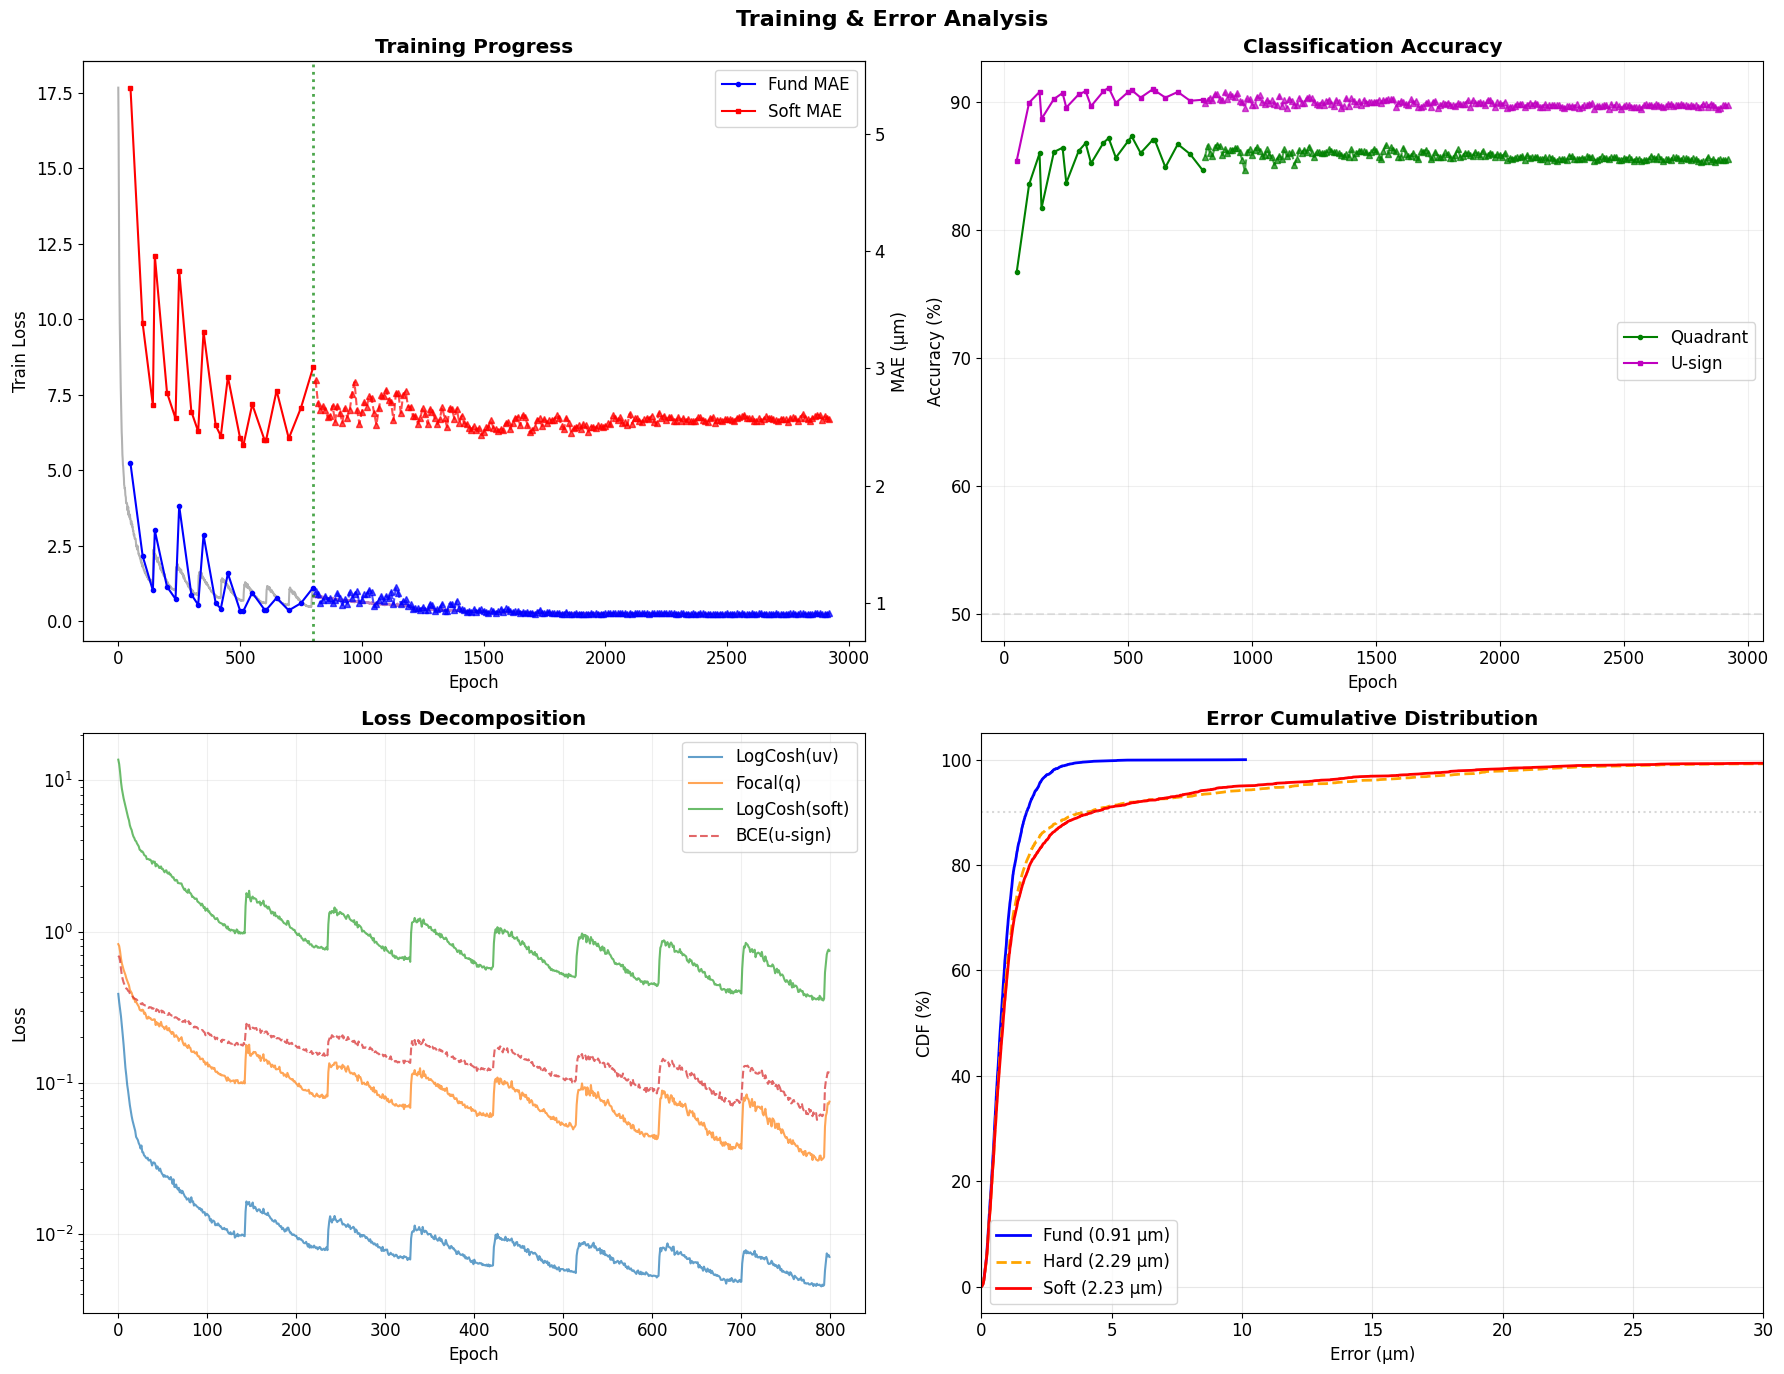

In [9]:
# ============================================================
# §8  Training Diagnostic Plots
# ============================================================

# Reconstruct validation epoch indices
val_epochs_p1 = []
for ep in range(1, EPOCHS + 1):
    if (ep % LOG_EVERY == 0) or (ep == EPOCHS) or (ep in checkpoint_epochs):
        val_epochs_p1.append(ep)
val_epochs_p1 = np.array(val_epochs_p1[:len(history['val_fund'])])

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1) Training loss + validation MAE
ax = axes[0, 0]
ax.plot(history['train_loss'], 'k-', alpha=0.3, label='Train loss')
if ft_history['loss']:
    ft_x = np.arange(EPOCHS + 1, EPOCHS + 1 + len(ft_history['loss']))
    ax.plot(ft_x, ft_history['loss'], 'purple', alpha=0.5, label='Phase 2 loss')
    ax.axvline(EPOCHS, color='green', ls=':', lw=2, alpha=0.7, label='Phase 2 start')
ax2 = ax.twinx()
ax2.plot(val_epochs_p1, history['val_fund'], 'b-o', ms=3, label='Fund MAE')
ax2.plot(val_epochs_p1, history['val_soft'], 'r-s', ms=3, label='Soft MAE')
if ft_history['val_ep']:
    ax2.plot(ft_history['val_ep'], ft_history['val_fund'], 'b--^', ms=4, alpha=0.7)
    ax2.plot(ft_history['val_ep'], ft_history['val_soft'], 'r--^', ms=4, alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss')
ax2.set_ylabel('MAE (µm)')
ax.set_title('Training Progress', fontweight='bold')
ax2.legend(loc='upper right')

# 2) Accuracy curves
ax = axes[0, 1]
ax.plot(val_epochs_p1, [a*100 for a in history['val_acc']], 'g-o', ms=3, label='Quadrant')
ax.plot(val_epochs_p1, [a*100 for a in history['val_usign_acc']], 'm-s', ms=3, label='U-sign')
if ft_history['val_ep']:
    ax.plot(ft_history['val_ep'], [a*100 for a in ft_history['val_acc']], 'g--^', ms=4, alpha=0.7)
    ax.plot(ft_history['val_ep'], [a*100 for a in ft_history['val_usign']], 'm--^', ms=4, alpha=0.7)
ax.axhline(50, color='gray', ls='--', alpha=0.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Classification Accuracy', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.2)

# 3) Loss decomposition
ax = axes[1, 0]
for key, label in [('train_fund','LogCosh(uv)'), ('train_focal','Focal(q)'),
                    ('train_soft','LogCosh(soft)'), ('train_usign','BCE(u-sign)')]:
    ax.plot(history[key], label=label, alpha=0.7, lw=1.5,
            ls='--' if 'usign' in key else '-')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss Decomposition', fontweight='bold')
ax.legend(); ax.set_yscale('log'); ax.grid(True, alpha=0.2)

# 4) Error CDF
ax = axes[1, 1]
for name, arr, color, ls in [('Fund', fund_err, 'blue', '-'),
                               ('Hard', hard_err, 'orange', '--'),
                               ('Soft', soft_err, 'red', '-')]:
    sorted_e = np.sort(arr)
    ax.plot(sorted_e, np.arange(1,len(sorted_e)+1)/len(sorted_e)*100,
            color=color, ls=ls, lw=2, label=f'{name} ({arr.mean():.2f} µm)')
ax.set_xlabel('Error (µm)'); ax.set_ylabel('CDF (%)')
ax.set_title('Error Cumulative Distribution', fontweight='bold')
ax.legend(); ax.set_xlim(0, 30); ax.grid(True, alpha=0.3)
ax.axhline(90, color='gray', ls=':', alpha=0.3)

plt.suptitle('Training & Error Analysis', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(f'{save_dir}fig1_training.png', dpi=150, bbox_inches='tight')
plt.show()

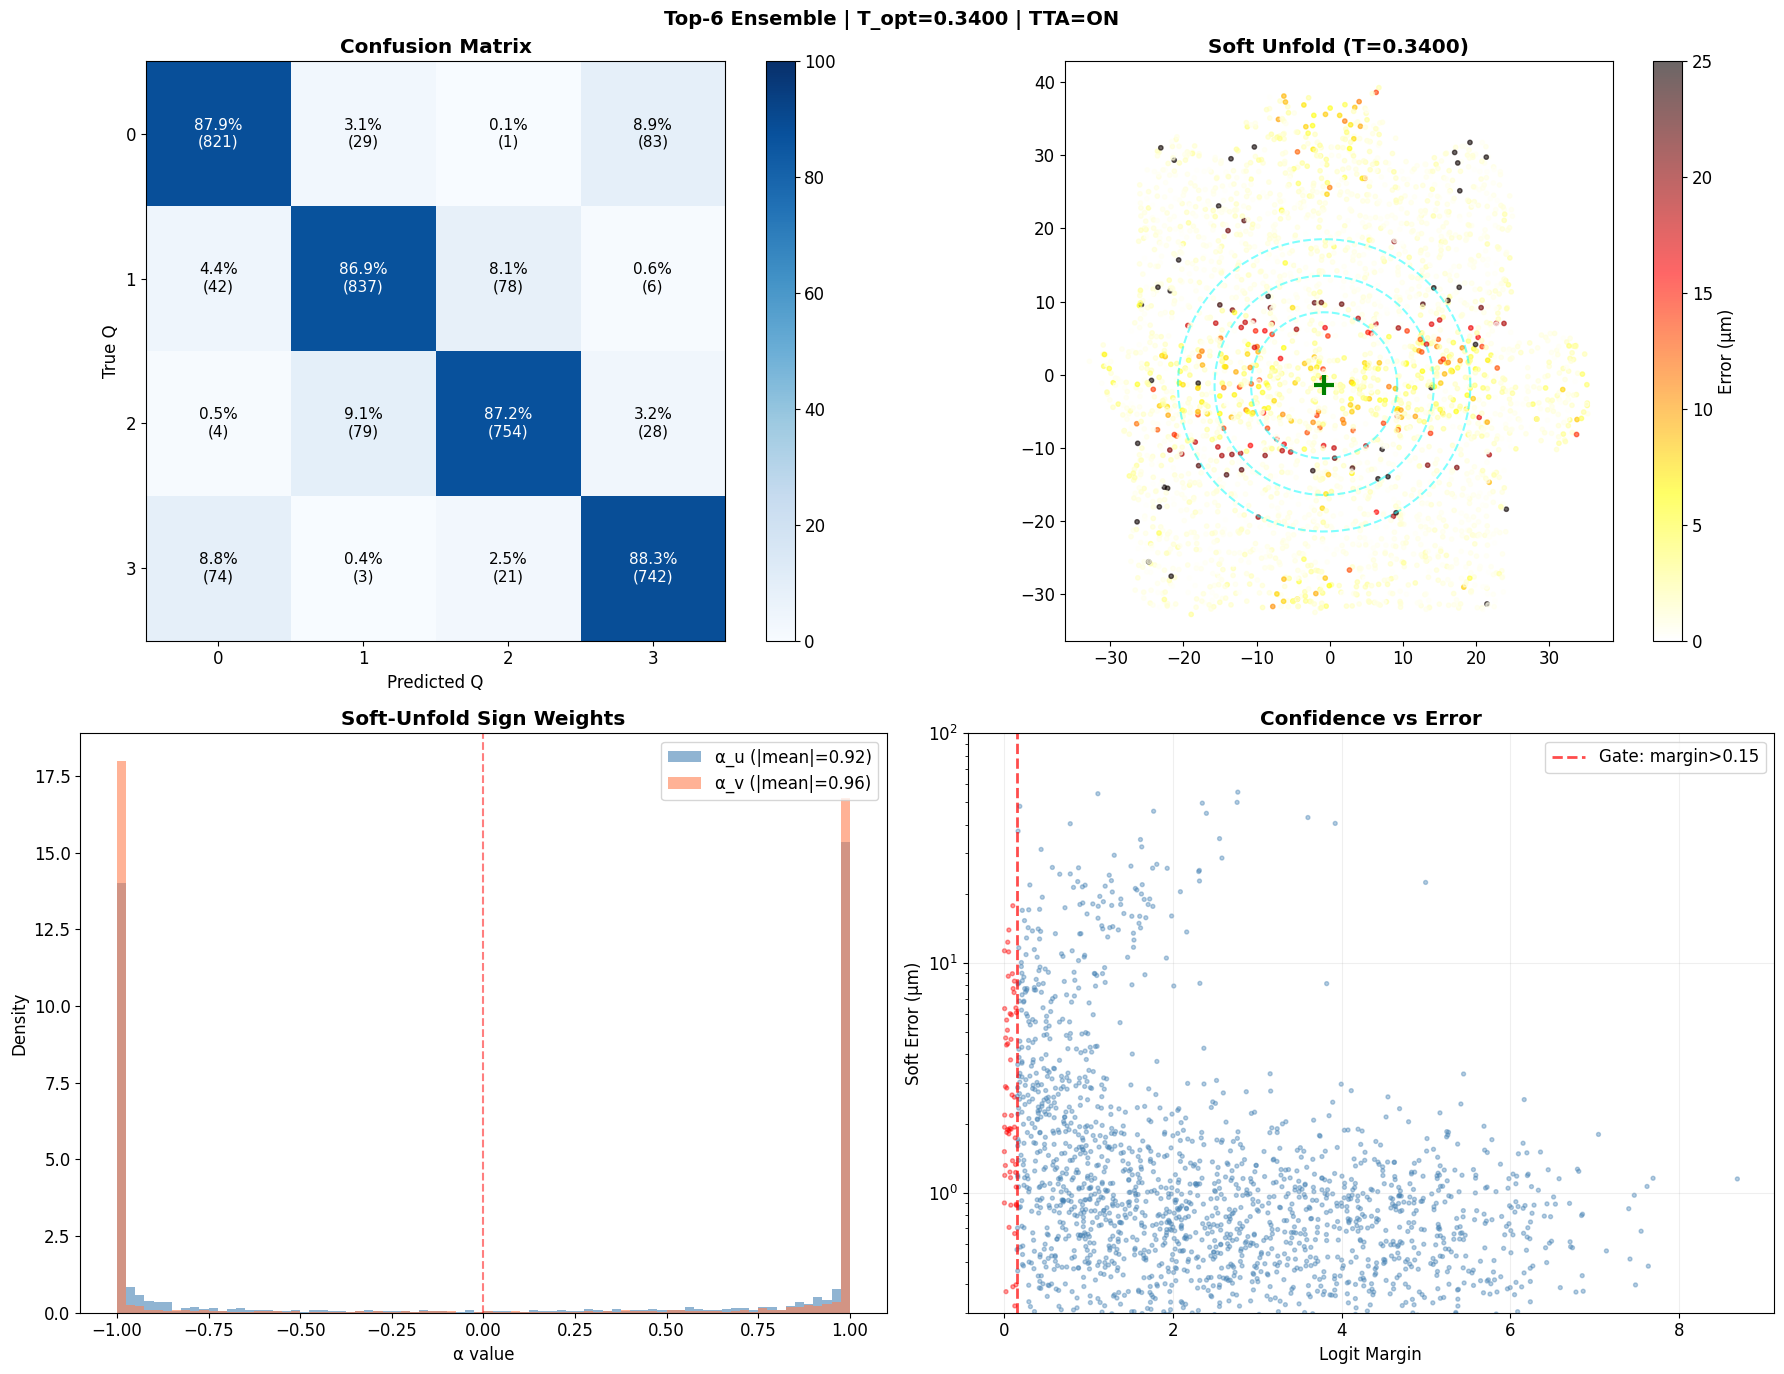

In [10]:
# ============================================================
# §9  Evaluation Plots: Confusion Matrix, Spatial Maps, Alpha Distribution
# ============================================================

# Compute alpha values for plotting
with torch.no_grad():
    probs = F.softmax(logits_final.to(device) / T_INFER_OPT, dim=1)
    alpha_u = (probs * U_SIGNS).sum(dim=1).cpu().numpy()
    alpha_v = (probs * V_SIGNS).sum(dim=1).cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1) Confusion matrix
ax = axes[0, 0]
cm_plot = confusion_matrix(q_true, q_pred, labels=[0,1,2,3])
cm_pct = cm_plot / cm_plot.sum(axis=1, keepdims=True) * 100
im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm_pct[i,j]:.1f}%\n({cm_plot[i,j]})',
                ha='center', va='center',
                color='white' if cm_pct[i,j] > 50 else 'black', fontsize=11)
ax.set_xlabel('Predicted Q'); ax.set_ylabel('True Q')
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
plt.colorbar(im, ax=ax)

# 2) Soft-unfold scatter with error coloring
ax = axes[0, 1]
subset = np.random.choice(len(x_soft), min(3000, len(x_soft)), replace=False)
sc_plot = ax.scatter(x_soft[subset], y_soft[subset], c=soft_err[subset],
                     s=10, alpha=0.6, cmap='hot_r', vmin=0, vmax=25)
ax.plot(X_C, Y_C, 'g+', ms=15, mew=3)
for r_fid in [10, 15, 20]:
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(X_C + r_fid*np.cos(theta), Y_C + r_fid*np.sin(theta),
            'cyan', ls='--', alpha=0.5)
ax.set_aspect('equal')
ax.set_title(f'Soft Unfold (T={T_INFER_OPT:.4f})', fontweight='bold')
plt.colorbar(sc_plot, ax=ax, label='Error (µm)')

# 3) Alpha distribution
ax = axes[1, 0]
ax.hist(alpha_u, bins=80, alpha=0.6, density=True,
        label=f'α_u (|mean|={np.abs(alpha_u).mean():.2f})', color='steelblue')
ax.hist(alpha_v, bins=80, alpha=0.6, density=True,
        label=f'α_v (|mean|={np.abs(alpha_v).mean():.2f})', color='coral')
ax.axvline(0, color='red', ls='--', alpha=0.5)
ax.set_xlabel('α value'); ax.set_ylabel('Density')
ax.set_title('Soft-Unfold Sign Weights', fontweight='bold'); ax.legend()

# 4) Confidence margin vs error
ax = axes[1, 1]
sub_m = np.random.choice(len(margin), min(2000, len(margin)), replace=False)
colors_m = np.where(conf_mask[sub_m], 'steelblue', 'red')
ax.scatter(margin[sub_m], soft_err[sub_m], c=colors_m, s=8, alpha=0.4)
if MARGIN_THRESH is not None:
    ax.axvline(MARGIN_THRESH, color='red', ls='--', lw=2, alpha=0.7,
               label=f'Gate: margin>{MARGIN_THRESH:.2f}')
ax.set_xlabel('Logit Margin'); ax.set_ylabel('Soft Error (µm)')
ax.set_title('Confidence vs Error', fontweight='bold')
ax.set_yscale('log'); ax.set_ylim(0.3, 100); ax.legend(); ax.grid(True, alpha=0.2)

plt.suptitle(f'{ens_label} Ensemble | T_opt={T_INFER_OPT:.4f} | '
             f'TTA={"ON" if tta_improves else "OFF"}',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{save_dir}fig2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

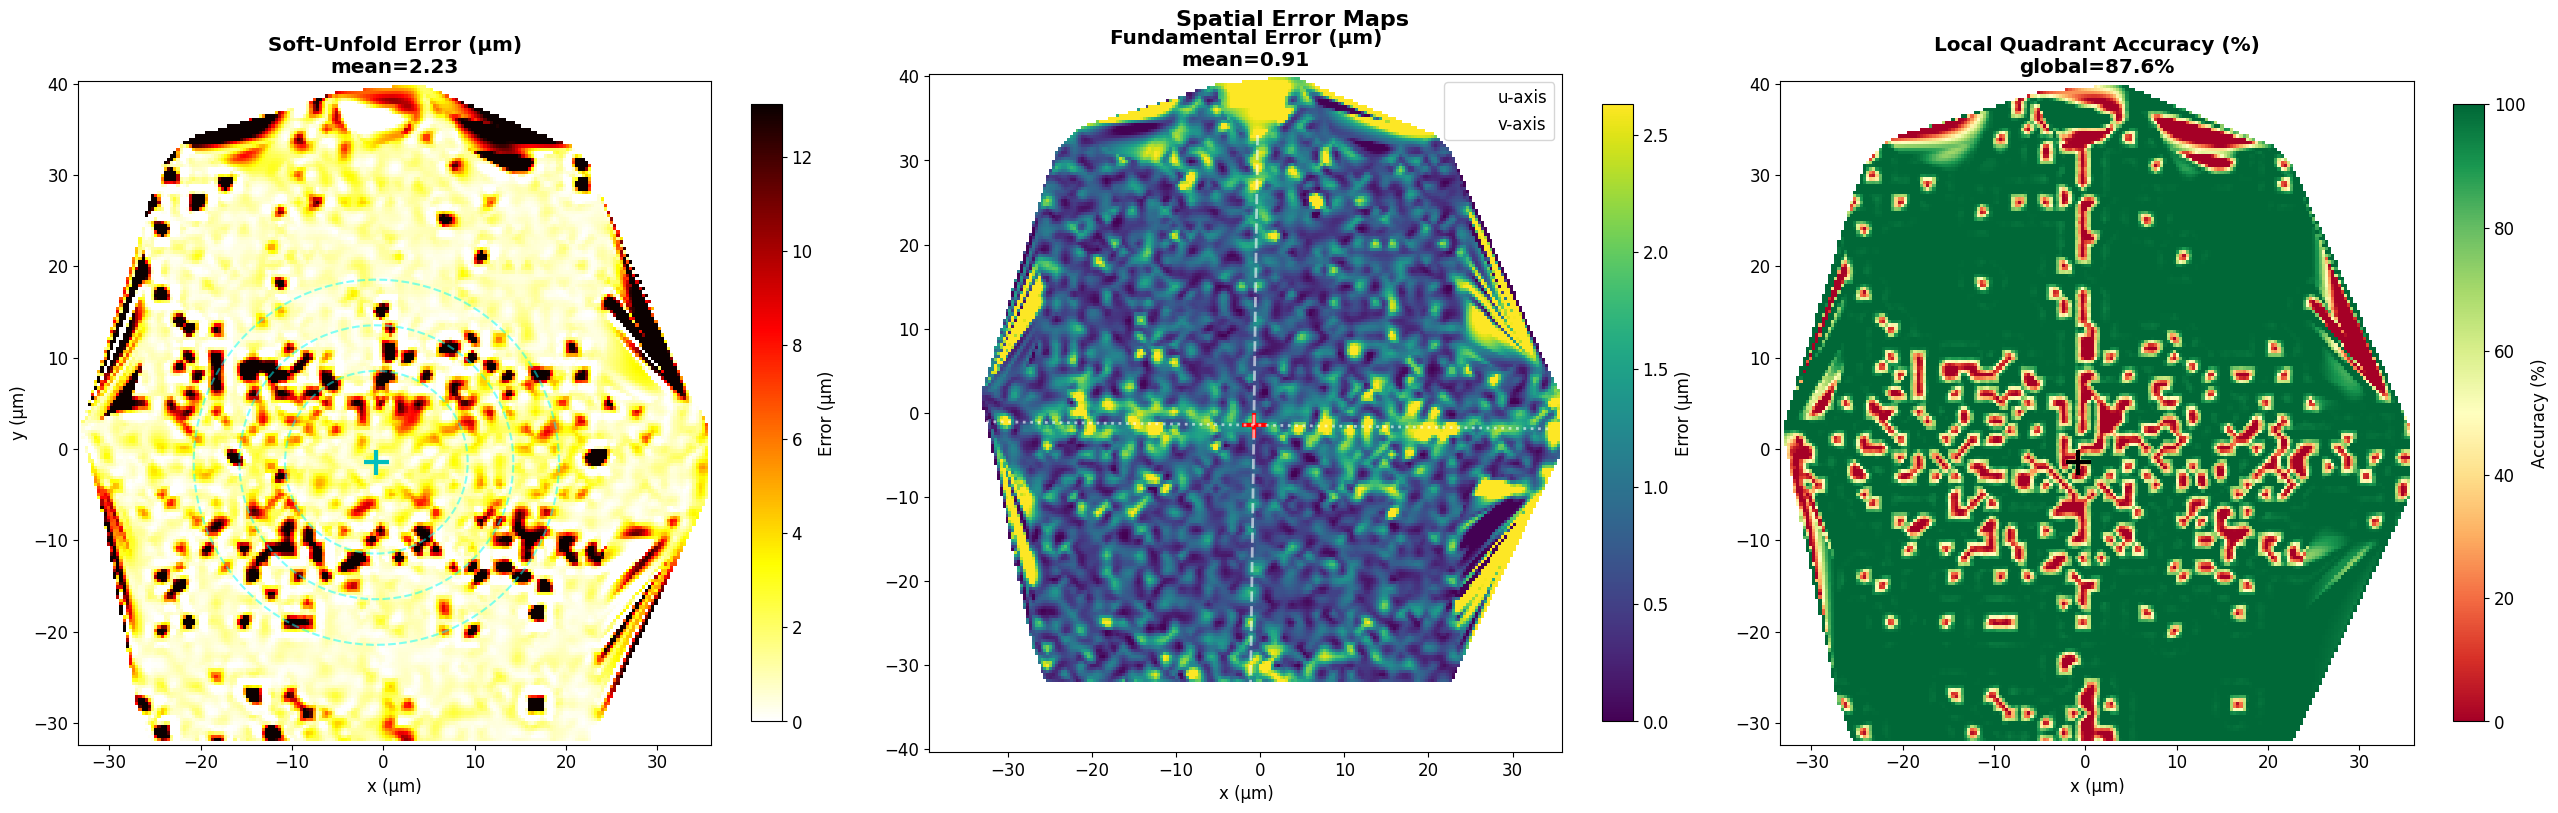

In [11]:
# ============================================================
# §10  Spatial Error Maps
# ============================================================
from scipy.interpolate import griddata

x_true_test, y_true_test = xy_true[:, 0], xy_true[:, 1]
N_GRID_MAP = 200
xi = np.linspace(x_true_test.min(), x_true_test.max(), N_GRID_MAP)
yi = np.linspace(y_true_test.min(), y_true_test.max(), N_GRID_MAP)
Xi, Yi = np.meshgrid(xi, yi)

Zi_soft = griddata((x_true_test, y_true_test), soft_err, (Xi, Yi), method='cubic', fill_value=np.nan)
Zi_fund = griddata((x_true_test, y_true_test), fund_err, (Xi, Yi), method='cubic', fill_value=np.nan)
Zi_acc  = griddata((x_true_test, y_true_test), correct,  (Xi, Yi), method='cubic', fill_value=np.nan)

fig, axes = plt.subplots(1, 3, figsize=(26, 8))

# Soft-unfold error map
ax = axes[0]
im0 = ax.pcolormesh(Xi, Yi, Zi_soft, cmap='hot_r', vmin=0,
                     vmax=np.nanpercentile(Zi_soft, 95), shading='auto')
ax.plot(X_C, Y_C, 'c+', ms=18, mew=3)
for r_fid in [10, 15, 20]:
    th = np.linspace(0, 2*np.pi, 100)
    ax.plot(X_C + r_fid*np.cos(th), Y_C + r_fid*np.sin(th), 'cyan', ls='--', alpha=0.5)
ax.set_title(f'Soft-Unfold Error (µm)\nmean={soft_err.mean():.2f}', fontweight='bold')
ax.set_aspect('equal'); ax.set_xlabel('x (µm)'); ax.set_ylabel('y (µm)')
plt.colorbar(im0, ax=ax, label='Error (µm)', shrink=0.85)

# Fundamental error map
ax = axes[1]
im1 = ax.pcolormesh(Xi, Yi, Zi_fund, cmap='viridis', vmin=0,
                     vmax=np.nanpercentile(Zi_fund, 95), shading='auto')
ax.plot(X_C, Y_C, 'r+', ms=18, mew=3)
phi_plot = np.radians(PHI0); L = 35
ax.plot([X_C - L*np.cos(phi_plot), X_C + L*np.cos(phi_plot)],
        [Y_C - L*np.sin(phi_plot), Y_C + L*np.sin(phi_plot)], 'w--', alpha=0.6, lw=2, label='u-axis')
ax.plot([X_C + L*np.sin(phi_plot), X_C - L*np.sin(phi_plot)],
        [Y_C - L*np.cos(phi_plot), Y_C + L*np.cos(phi_plot)], 'w:', alpha=0.6, lw=2, label='v-axis')
ax.set_title(f'Fundamental Error (µm)\nmean={fund_mae:.2f}', fontweight='bold')
ax.set_aspect('equal'); ax.set_xlabel('x (µm)'); ax.legend()
plt.colorbar(im1, ax=ax, label='Error (µm)', shrink=0.85)

# Accuracy map
ax = axes[2]
im2 = ax.pcolormesh(Xi, Yi, Zi_acc * 100, cmap='RdYlGn', vmin=0, vmax=100, shading='auto')
ax.plot(X_C, Y_C, 'k+', ms=18, mew=3)
ax.set_title(f'Local Quadrant Accuracy (%)\nglobal={acc_total:.1%}', fontweight='bold')
ax.set_aspect('equal'); ax.set_xlabel('x (µm)')
plt.colorbar(im2, ax=ax, label='Accuracy (%)', shrink=0.85)

plt.suptitle('Spatial Error Maps', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(f'{save_dir}fig3_error_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# §11  Summary and Model Export
# ============================================================

print('=' * 70)
print('FINAL RESULTS')
print('=' * 70)

print(f'''
Architecture: MultiDomainCNN ({n_params:,} parameters)
  CNN: 2-channel (wf + dV/dt) → 128-d
  MLP: {N_MLP_IN} features → 128-d
  Fusion: 256 → 128 → 3 heads (xy, sector, u-sign)

Training: Phase 1 ({EPOCHS}ep CosineWR) + Phase 2 ({ep_ft}ep ReduceLR)
  Loss: LogCosh + Focal(γ=2, α=[0.9,0.9,1.0,1.3]) + Soft-unfold + BCE(u-sign)

Post-processing: {final_label}
  Ensemble: {ens_label}
  T_INFER_OPT: {T_INFER_OPT:.4f}
  Gate: {"margin>" + f"{MARGIN_THRESH:.2f}" + f", T_fb={T_FALLBACK}" if use_gate else "OFF"}
  TTA: N={N_TTA} {"(active)" if tta_improves else "(no improvement)"}

Metrics:
  Fund MAE:     {fund_mae:.2f} µm
  Accuracy:     {acc_total:.1%}
  Hard unfold:  {hard_err.mean():.2f} µm
  Soft unfold:  {soft_err.mean():.2f} µm
  U-sign acc:   {usign_acc_final:.1%}

Percentiles (Soft):
  P50={np.percentile(soft_err,50):.1f}  P90={np.percentile(soft_err,90):.1f}  P95={np.percentile(soft_err,95):.1f}  P99={np.percentile(soft_err,99):.1f}  Max={soft_err.max():.1f} µm
''')

# Historical comparison
print('Historical comparison:')
print(f'  {"Version":<8} {"MLP":>5} {"Fund":>6} {"Acc":>7} {"Hard":>7} {"Soft":>7} {"U-sign":>7}')
print(f'  {"-"*50}')
for v, mlp, fu, ac, ha, so, us in [
    ('v5.1',  '36', '3.25', '70.5%', '7.57', '7.46', '—'),
    ('v5.7',  '36', '3.39', '73.1%', '7.15', '6.65', '—'),
    ('v5.9',  '66', '2.25', '81.2%', '4.29', '4.06', '—'),
    ('v5.22', '99', '1.49', '86.4%', '3.23', '3.14', '90.1%'),
    ('v5.23','100', '0.84', '88.2%', '2.31', '2.24', '91.2%'),]:
    print(f'  {v:<8} {mlp:>5} {fu:>6} {ac:>7} {ha:>7} {so:>7} {us:>7}')
print(f'  {"v5.24":<8} {N_MLP_IN:>5} {fund_mae:>6.2f} {acc_total:>6.1%} '
      f'{hard_err.mean():>7.2f} {soft_err.mean():>7.2f} {usign_acc_final:>6.1%}  <-- THIS')

# --- Save model ---
save_dict = {
    'version': '5.24',
    'architecture': 'MultiDomainCNN',
    'snapshots': [{'epoch': s['epoch'], 'state_dict': s['state']}
                  for s in all_snapshots],
    'ensemble_idxs': [int(i) for i in ens_idxs],
    'T_INFER_OPT': float(T_INFER_OPT),
    'margin_thresh': float(MARGIN_THRESH) if MARGIN_THRESH is not None else None,
    'T_fallback': float(T_FALLBACK) if T_FALLBACK is not None else None,
    'use_tta': tta_improves, 'N_TTA': N_TTA,
    'target_mean': target_scaler.mean_.tolist(),
    'target_scale': target_scaler.scale_.tolist(),
    'X_C': X_C, 'Y_C': Y_C, 'PHI0': PHI0,
    'N_SCALARS': N_SCALARS, 'N_ASYM_WF': N_ASYM_WF,
    'N_ASYM_DERIV': N_ASYM_DERIV, 'N_ASYM_FFT': N_ASYM_FFT,
    'N_IRREP': N_IRREP, 'N_MLP_IN': N_MLP_IN,
    'n_params': n_params,
    'metrics': {
        'fund_mae': float(fund_mae), 'acc_total': float(acc_total),
        'hard_mae': float(hard_err.mean()), 'soft_mae': float(soft_err.mean()),
        'usign_acc': float(usign_acc_final),
    },
}

save_path = f'{save_dir}model_v524.pt'
torch.save(save_dict, save_path)
fsize = os.path.getsize(save_path) / 1e6
print(f'\nModel saved: {save_path} ({fsize:.1f} MB)')
print('=' * 70)

FINAL RESULTS

Architecture: MultiDomainCNN (354,375 parameters)
  CNN: 2-channel (wf + dV/dt) → 128-d
  MLP: 110 features → 128-d
  Fusion: 256 → 128 → 3 heads (xy, sector, u-sign)

Training: Phase 1 (800ep CosineWR) + Phase 2 (2120ep ReduceLR)
  Loss: LogCosh + Focal(γ=2, α=[0.9,0.9,1.0,1.3]) + Soft-unfold + BCE(u-sign)

Post-processing: E) +TTA
  Ensemble: Top-6
  T_INFER_OPT: 0.3400
  Gate: margin>0.15, T_fb=1.0
  TTA: N=10 (active)

Metrics:
  Fund MAE:     0.91 µm
  Accuracy:     87.6%
  Hard unfold:  2.29 µm
  Soft unfold:  2.23 µm
  U-sign acc:   91.1%

Percentiles (Soft):
  P50=0.8  P90=4.3  P95=9.9  P99=24.4  Max=60.5 µm

Historical comparison:
  Version    MLP   Fund     Acc    Hard    Soft  U-sign
  --------------------------------------------------
  v5.1        36   3.25   70.5%    7.57    7.46       —
  v5.7        36   3.39   73.1%    7.15    6.65       —
  v5.9        66   2.25   81.2%    4.29    4.06       —
  v5.22       99   1.49   86.4%    3.23    3.14   90.1%
  v5

---

## Summary

This notebook implements the complete **training and evaluation pipeline** for
sub-pixel position reconstruction in a 3D silicon detector pixel using TPA-TCT.

**Input:** `model_input.npz` — pre-processed features exported by **NB_Feature_Engineering**.
No feature engineering is performed here; the notebook receives ready-to-train tensors.

**Pipeline (§1–§11):**

| Section | Content |
|---------|---------|
| §1 | Load `model_input.npz` (110-d MLP, 2-ch CNN, targets, geometry, split) |
| §2 | PyTorch Dataset / DataLoader |
| §3 | MultiDomainCNN architecture (CNN + MLP + fusion → 3 heads) |
| §4 | Composite loss: LogCosh + Focal + Soft-Unfold + U-sign BCE |
| §5a | Phase 1: CosineAnnealingWarmRestarts (800 ep, 8 snapshots) |
| §5b | Phase 2: ReduceLROnPlateau fine-tuning |
| §6 | Post-training: Ensemble → T-opt → Confidence gate → TTA |
| §7 | Fiducial cuts and ablation table |
| §8–§10 | Diagnostic, evaluation, and spatial error plots |
| §11 | Final summary and model export |

**Key design choices:**

| Design decision | Rationale |
|----------------|-----------|
| Dual-branch CNN+MLP | CNN extracts waveform morphology; MLP leverages physics-informed features |
| C₂v fundamental domain | Reduces 4-fold symmetry ambiguity to a sign-recovery problem |
| Four-term loss | Balances regression accuracy, classification, spatial consistency, and u-sign discrimination |
| Two-phase training | Cosine exploration + plateau convergence for robust optimisation |
| Post-processing cascade | Ensemble → T-opt → gate → TTA systematically squeezes residual error |
| Confidence fiducial cuts | Enables quality-selectable reconstruction for downstream physics |
| Deterministic algorithms | `torch.use_deterministic_algorithms(True)` for full reproducibility |

**Hyperparameters:** Optuna HPO v4, trial #1 (Soft=2.127 µm) — precision-focused, symmetry locked from trial #71

---
*Author: Ibon · Research Project · 2026*